In [22]:
options(stringsAsFactors = F)
Sys.setenv(LANGUAGE = "en")

library("ggplot2")
library("scales")
library("RColorBrewer")
library("ggsci")
library("ggpubr")
suppressPackageStartupMessages(library(dplyr))
library('ggprism')
library('patchwork')
suppressPackageStartupMessages(library("tidyverse"))

In [23]:
mytheme<-theme(
legend.title = element_blank(),legend.position = "top",
panel.border = element_rect(color = "black", linewidth = 1.5),  
panel.grid = element_blank(),axis.title = element_text(size=14),
plot.title = element_text(hjust = 0.5, face="bold", color="black", size=24),
axis.line=element_line(linewidth=1,colour="black"),
axis.ticks=element_line(linewidth=1,colour="black"),axis.ticks.length=unit(0.5,"lines"),
title=element_text(face="bold", colour= "black", size=14),
axis.text.x = element_text(face="bold", color="black", size=14, angle=0),# vjust=0.85, hjust=0.75),
axis.text.y = element_text(face="bold", color="black", size=14),
legend.text = element_text(face="bold", color="black", size=14),
axis.title.x = element_text(face="bold", color="black", size=14),
axis.title.y = element_text(face="bold",color="black", size=14))
mytheme = mytheme+ggplot2::theme(legend.text = element_text(size = 14,face = "bold",color = "black"))

SEM_ebtop<-function(x){
  return(mean(x)+(sd(x)/sqrt(length(x))))
}
SEM_ebbottom<-function(x){
  #return(mean(x)-(sd(x)/sqrt(length(x))))
  return(mean(x))
}

In [39]:
data = readr::read_tsv("Merged_Metric.tsv", skip = 0, comment = "#", col_names = TRUE, progress =FALSE, show_col_types = FALSE)

df_combined <- data %>%
  group_by(Tools, Depth) %>%
  summarise(
    mean_F1 = mean(F1score, na.rm = TRUE),
    F1_se = sd(F1score, na.rm = TRUE) / sqrt(n()),
    mean_BPD = mean(Base_pair_Difference, na.rm = TRUE),
    BPD_se = sd(Base_pair_Difference, na.rm = TRUE) / sqrt(n()),
    mean_Accuracy = mean(Accuracy, na.rm = TRUE),
    Accuracy_se = sd(Accuracy, na.rm = TRUE) / sqrt(n()),
    mean_Precision = mean(Precision, na.rm = TRUE),
    Precision_se = sd(Precision, na.rm = TRUE) / sqrt(n()),
    mean_Sensitivity = mean(Sensitivity, na.rm = TRUE),
    Sensitivity_se = sd(Sensitivity, na.rm = TRUE) / sqrt(n()),
    mean_Specificity = mean(Specificity, na.rm = TRUE),
    Specificity_se = sd(Specificity, na.rm = TRUE) / sqrt(n()),
    mean_Base_pair_Difference = mean(Base_pair_Difference, na.rm = TRUE),
    Base_pair_Difference_se = sd(Base_pair_Difference, na.rm = TRUE) / sqrt(n()),
    mean_Redundancy = mean(Redundancy, na.rm = TRUE),
    Redundancy_se = sd(Redundancy, na.rm = TRUE) / sqrt(n()),
    n = n(),
    
    .groups = 'drop' 
  )

head(df_combined)

Tools,Depth,mean_F1,F1_se,mean_BPD,BPD_se,mean_Accuracy,Accuracy_se,mean_Precision,Precision_se,mean_Sensitivity,Sensitivity_se,mean_Specificity,Specificity_se,mean_Base_pair_Difference,Base_pair_Difference_se,mean_Redundancy,Redundancy_se,n
<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
CircleMap,10X,0.8892162,0.02276757,20.56000,10.83133,0.8936021,0.02202340,0.8664565,0.04747822,0.9149000,0.01839411,0.8760414,0.04515131,20.56000,10.83133,1.255714,0.1137039,7
CircleMap,15X,0.8853364,0.02700794,25.10429,13.89081,0.8889868,0.02659964,0.8475501,0.05788053,0.9292714,0.01555450,0.8562298,0.05592650,25.10429,13.89081,1.321429,0.1522529,7
CircleMap,20X,0.8844793,0.02843794,29.30857,16.42686,0.8877531,0.02828650,0.8413755,0.06319280,0.9356000,0.01623196,0.8493122,0.06167131,29.30857,16.42686,1.377143,0.1909375,7
CircleMap,25X,0.8850742,0.02822150,31.96714,18.10799,0.8881864,0.02816813,0.8405979,0.06378272,0.9380571,0.01713076,0.8481770,0.06246493,31.96714,18.10799,1.421429,0.2158262,7
CircleMap,30X,0.8848299,0.02950091,34.54714,19.90528,0.8878202,0.02943839,0.8385553,0.06581408,0.9402429,0.01672292,0.8459042,0.06450475,34.54714,19.90528,1.455714,0.2464993,7
CircleMap,35X,0.8853773,0.03000027,36.28143,20.61891,0.8883040,0.02991777,0.8388655,0.06658156,0.9411143,0.01587634,0.8460836,0.06517985,36.28143,20.61891,1.484286,0.2608229,7


In [44]:
df_combined$Tools = factor(df_combined$Tools, levels=c("Deep_EccScan", "CircleMap", "Circle_finder", "ecc_finder", "ECCsplorer"))
df_combined$Depth = factor(df_combined$Depth, levels=c("50X", "45X", "40X", "35X", "30X", "25X", "20X", "15X", "10X", "5X"))

df_combined_50X = subset(df_combined, df_combined$Depth == '50X')

In [45]:
df_combined_50X <- df_combined_50X %>%
  mutate(across(where(is.numeric), ~ sprintf("%.2f", .)))

write.table(df_combined_50X, "df_combined_50X.tsv", sep = "\t", row.names = FALSE, quote = FALSE)

`height` was translated to `width`.
`height` was translated to `width`.


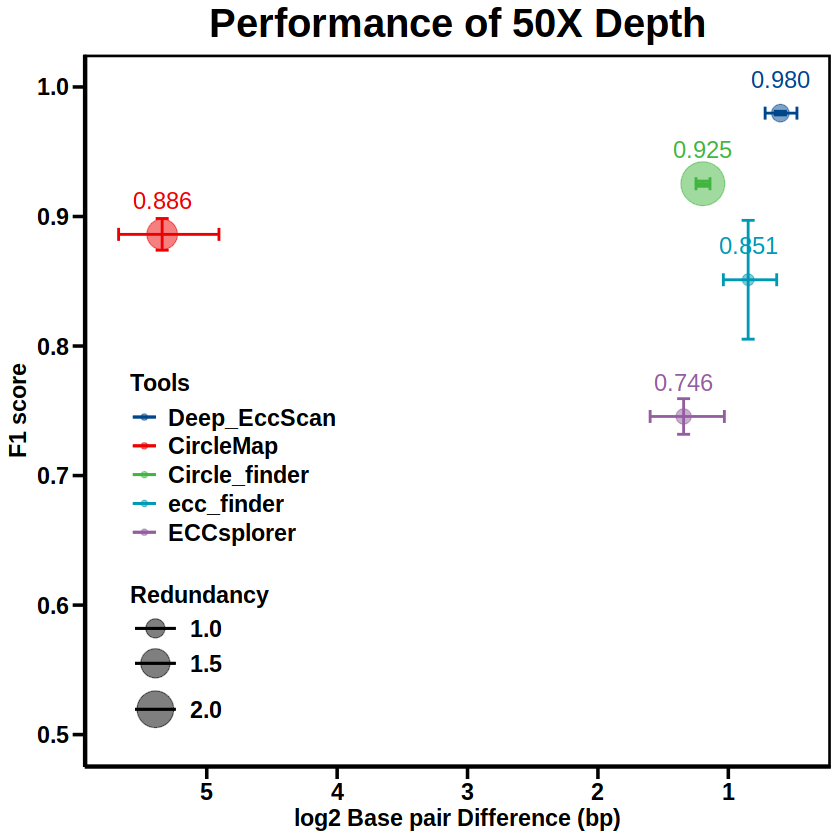

In [124]:
#50X Performance
p1=ggplot(df_combined_50X, aes(x = log2(mean_BPD), y = mean_F1, size = mean_Redundancy, shape = Tools, color = Tools, group = Tools)) +
  geom_point(shape = 19, alpha =0.5) +
  scale_size_continuous(name = "Redundancy", range = c(3, 12), breaks = c(1.1, 1.5, 2.0), labels = c("1.0", "1.5", "2.0")) +
  geom_errorbar(aes(ymin = mean_F1 - F1_se, ymax = mean_F1 + F1_se), linewidth= 0.8, width = 0.1) +
  geom_errorbarh(aes(xmin = log2(mean_BPD - BPD_se), xmax = log2(mean_BPD + BPD_se)), linewidth= 0.8, height = 0.01) +
  geom_text(aes(label = sprintf("%.3f", mean_F1)), 
            vjust = -1.5, 
            hjust = 0.5,
            size = 5,
            show.legend = FALSE) +
  scale_x_reverse() +  
  ylim(0.5, 1)+
  scale_color_lancet() +
  labs(title = "",
       x = "log2 Base pair Difference (bp)", 
       y = "F1 score") +
   ggtitle("Performance of 50X Depth") +
   theme_bw() +
   theme(
    legend.title = element_text(face="bold", colour= "black", size=14),legend.position = c(0.2, 0.3),
    panel.grid = element_blank(),axis.title = element_text(size=14),
    panel.border = element_rect(fill="NA",color="black", size=1.5, linetype="solid"),
    plot.title = element_text(hjust = 0.5, face="bold", color="black", size=24),
    axis.line=element_line(linewidth=1,colour="black"),
    axis.ticks=element_line(linewidth=1,colour="black"),axis.ticks.length=unit(0.5,"lines"),
    title=element_text(face="bold", colour= "black", size=14),
    axis.text.x = element_text(face="bold", color="black", size=14),
    axis.text.y = element_text(face="bold", color="black", size=14),
    legend.text = element_text(face="bold", color="black", size=14),
    axis.title.x = element_text(face="bold", color="black", size=14),
    axis.title.y = element_text(face="bold",color="black", size=14))

p1
#ggsave(p1,file="Performance_50X_F1_BPD.pdf",w=6, h=6)

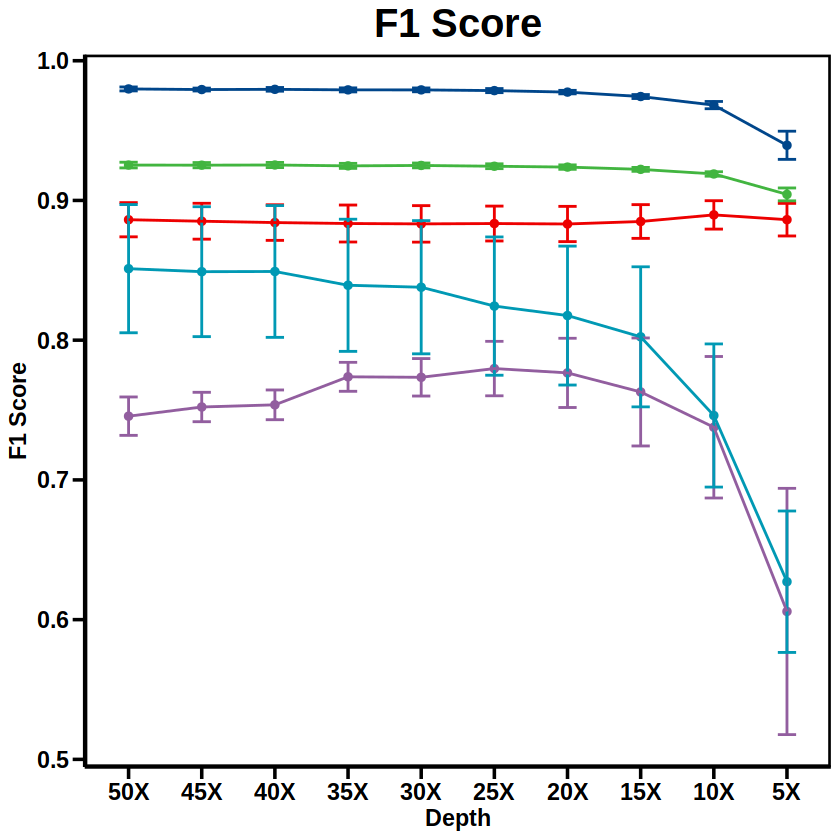

In [155]:
p2 =ggplot(df_combined, aes(x = Depth, y = mean_F1, , shape = Tools, color = Tools)) +
    geom_point(aes(x = Depth, y = mean_F1, fill = Tools), shape =19, size = 2) +
    geom_errorbar(aes(x = Depth, ymin = mean_F1 - F1_se, ymax = mean_F1 + F1_se), width = 0.25,linewidth= 0.8) + 
    geom_line(aes(group=Tools,color=Tools), size=0.8) +
    ggsci::scale_fill_lancet() +
    ggsci::scale_color_lancet()+
    ggtitle("F1 Score")+
    theme_bw()+xlab(label = "Depth")+ylab(label = "F1 Score")+
    theme(
    legend.title = element_blank(),legend.position = "none",
    panel.grid = element_blank(),axis.title = element_text(size=14),
    panel.border = element_rect(fill="NA",color="black", size=1.5, linetype="solid"),
    plot.title = element_text(hjust = 0.5, face="bold", color="black", size=24),
    axis.line=element_line(linewidth=1,colour="black"),
    axis.ticks=element_line(linewidth=1,colour="black"),axis.ticks.length=unit(0.5,"lines"),
    title=element_text(face="bold", colour= "black", size=14),
    axis.text.x = element_text(face="bold", color="black", size=14),
    axis.text.y = element_text(face="bold", color="black", size=14),
    legend.text = element_text(face="bold", color="black", size=14),
    axis.title.x = element_text(face="bold", color="black", size=14),
    axis.title.y = element_text(face="bold",color="black", size=14))

p2
#ggsave(p2, file="Performance_F1.pdf", w=6,h=6)

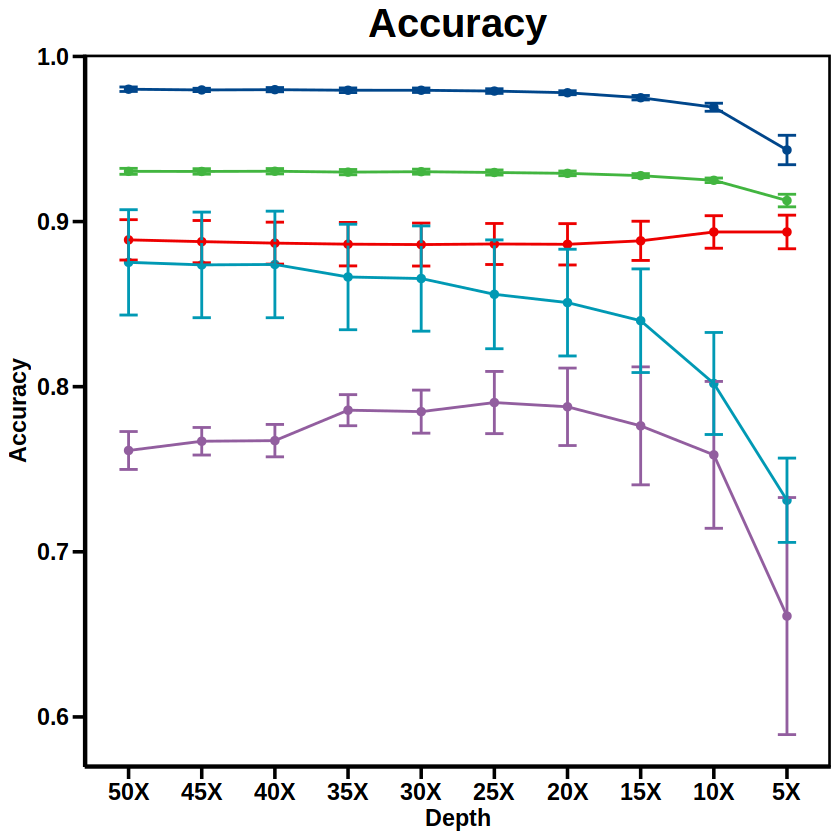

In [156]:
p3 =ggplot(df_combined, aes(x = Depth, y = mean_Accuracy, , shape = Tools, color = Tools)) +
    geom_point(aes(x = Depth, y = mean_Accuracy, fill = Tools), shape =19, size = 2) +
    geom_errorbar(aes(x = Depth, ymin = mean_Accuracy - Accuracy_se, ymax = mean_Accuracy + Accuracy_se), width = 0.25,linewidth= 0.8) + 
    geom_line(aes(group=Tools,color=Tools), size=0.8) +
    ggsci::scale_fill_lancet() +
    ggsci::scale_color_lancet()+
    ggtitle("Accuracy")+
    theme_bw()+xlab(label = "Depth")+ylab(label = "Accuracy")+
    theme(
    legend.title = element_blank(),legend.position = "none",
    panel.grid = element_blank(),axis.title = element_text(size=14),
    panel.border = element_rect(fill="NA",color="black", size=1.5, linetype="solid"),
    plot.title = element_text(hjust = 0.5, face="bold", color="black", size=24),
    axis.line=element_line(linewidth=1,colour="black"),
    axis.ticks=element_line(linewidth=1,colour="black"),axis.ticks.length=unit(0.5,"lines"),
    title=element_text(face="bold", colour= "black", size=14),
    axis.text.x = element_text(face="bold", color="black", size=14),
    axis.text.y = element_text(face="bold", color="black", size=14),
    legend.text = element_text(face="bold", color="black", size=14),
    axis.title.x = element_text(face="bold", color="black", size=14),
    axis.title.y = element_text(face="bold",color="black", size=14))

p3
#ggsave(p3, file="Performance_Accuracy.pdf", w=6,h=6)

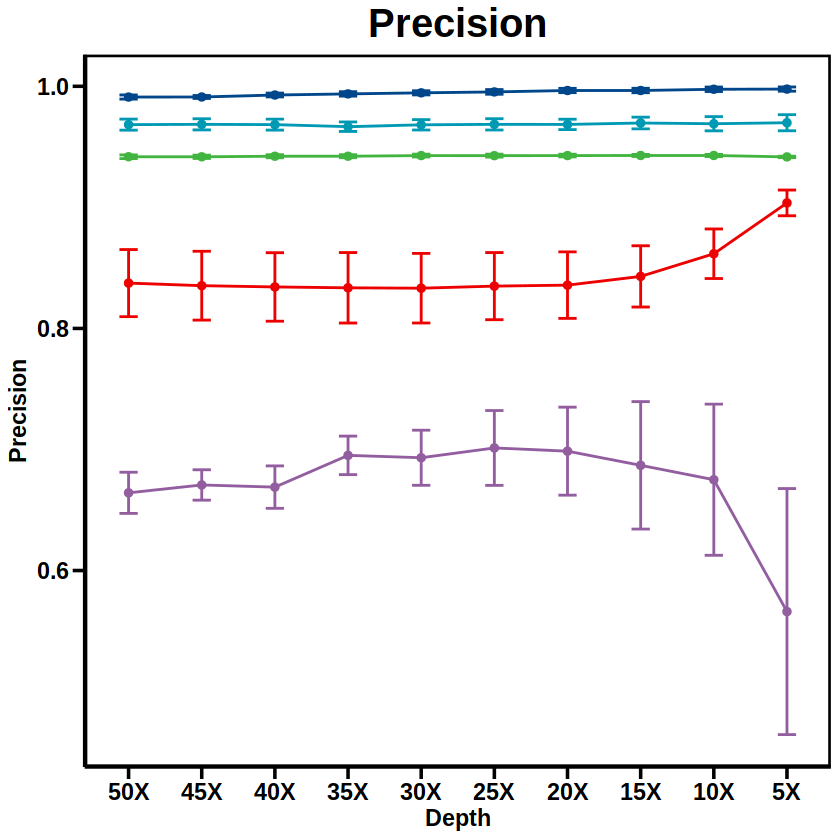

In [157]:
p4 =ggplot(df_combined, aes(x = Depth, y = mean_Precision, , shape = Tools, color = Tools)) +
    geom_point(aes(x = Depth, y = mean_Precision, fill = Tools), shape =19, size = 2) +
    geom_errorbar(aes(x = Depth, ymin = mean_Precision - Precision_se, ymax = mean_Precision + Precision_se), width = 0.25,linewidth= 0.8) + 
    geom_line(aes(group=Tools,color=Tools), size=0.8) +
    ggsci::scale_fill_lancet() +
    ggsci::scale_color_lancet()+
    ggtitle("Precision")+
    theme_bw()+xlab(label = "Depth")+ylab(label = "Precision")+
    theme(
    legend.title = element_blank(),legend.position = "none",
    panel.grid = element_blank(),axis.title = element_text(size=14),
    panel.border = element_rect(fill="NA",color="black", size=1.5, linetype="solid"),
    plot.title = element_text(hjust = 0.5, face="bold", color="black", size=24),
    axis.line=element_line(linewidth=1,colour="black"),
    axis.ticks=element_line(linewidth=1,colour="black"),axis.ticks.length=unit(0.5,"lines"),
    title=element_text(face="bold", colour= "black", size=14),
    axis.text.x = element_text(face="bold", color="black", size=14),
    axis.text.y = element_text(face="bold", color="black", size=14),
    legend.text = element_text(face="bold", color="black", size=14),
    axis.title.x = element_text(face="bold", color="black", size=14),
    axis.title.y = element_text(face="bold",color="black", size=14))

p4
#ggsave(p4, file="Performance_Precision.pdf", w=6,h=6)

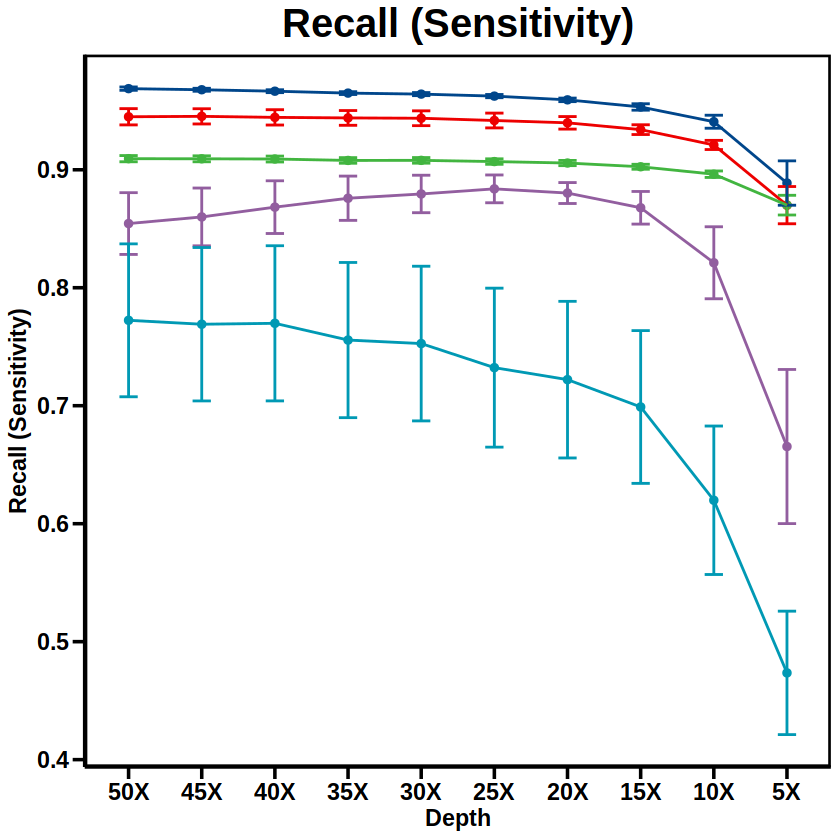

In [158]:
p5 =ggplot(df_combined, aes(x = Depth, y = mean_Sensitivity, , shape = Tools, color = Tools)) +
    geom_point(aes(x = Depth, y = mean_Sensitivity, fill = Tools), shape =19, size = 2) +
    geom_errorbar(aes(x = Depth, ymin = mean_Sensitivity - Sensitivity_se, ymax = mean_Sensitivity + Sensitivity_se), width = 0.25,linewidth= 0.8) + 
    geom_line(aes(group=Tools,color=Tools), size=0.8) +
    ggsci::scale_fill_lancet() +
    ggsci::scale_color_lancet()+
    ggtitle("Recall (Sensitivity)")+
    theme_bw()+xlab(label = "Depth")+ylab(label = "Recall (Sensitivity)")+
    theme(
    legend.title = element_blank(),legend.position = "none",
    panel.grid = element_blank(),axis.title = element_text(size=14),
    panel.border = element_rect(fill="NA",color="black", size=1.5, linetype="solid"),
    plot.title = element_text(hjust = 0.5, face="bold", color="black", size=24),
    axis.line=element_line(linewidth=1,colour="black"),
    axis.ticks=element_line(linewidth=1,colour="black"),axis.ticks.length=unit(0.5,"lines"),
    title=element_text(face="bold", colour= "black", size=14),
    axis.text.x = element_text(face="bold", color="black", size=14),
    axis.text.y = element_text(face="bold", color="black", size=14),
    legend.text = element_text(face="bold", color="black", size=14),
    axis.title.x = element_text(face="bold", color="black", size=14),
    axis.title.y = element_text(face="bold",color="black", size=14))

p5
#ggsave(p5, file="Performance_Sensitivity.pdf", w=6,h=6)

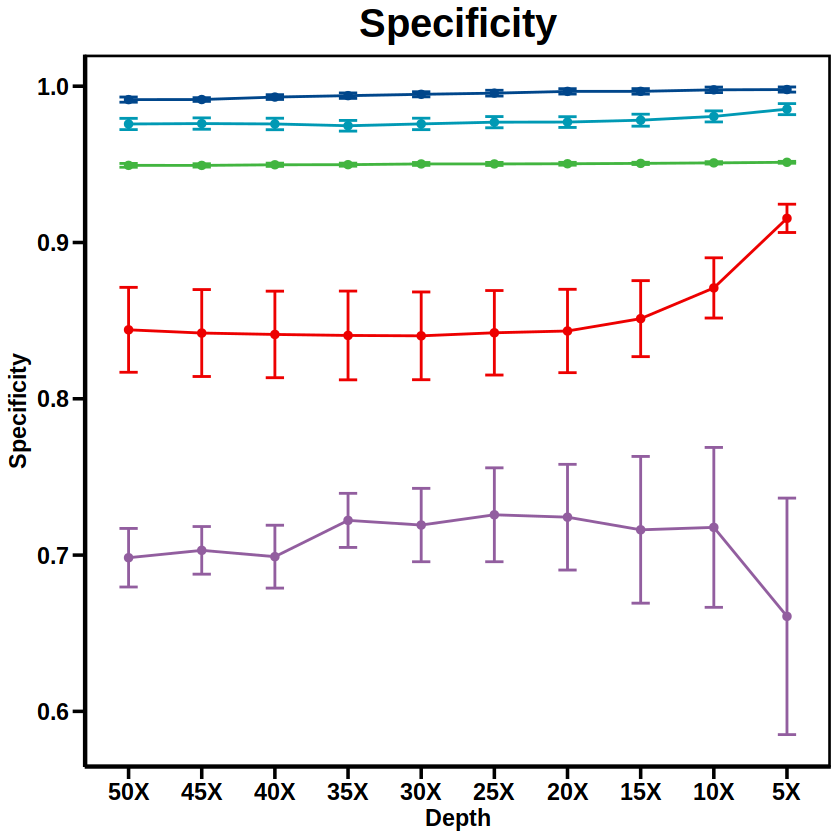

In [159]:
p6 =ggplot(df_combined, aes(x = Depth, y = mean_Specificity, , shape = Tools, color = Tools)) +
    geom_point(aes(x = Depth, y = mean_Specificity, fill = Tools), shape =19, size = 2) +
    geom_errorbar(aes(x = Depth, ymin = mean_Specificity - Specificity_se, ymax = mean_Specificity + Specificity_se), width = 0.25,linewidth= 0.8) + 
    geom_line(aes(group=Tools,color=Tools), size=0.8) +
    ggsci::scale_fill_lancet() +
    ggsci::scale_color_lancet()+
    ggtitle("Specificity")+
    theme_bw()+xlab(label = "Depth")+ylab(label = "Specificity")+
    theme(
    legend.title = element_blank(),legend.position = "none",
    panel.grid = element_blank(),axis.title = element_text(size=14),
    panel.border = element_rect(fill="NA",color="black", size=1.5, linetype="solid"),
    plot.title = element_text(hjust = 0.5, face="bold", color="black", size=24),
    axis.line=element_line(linewidth=1,colour="black"),
    axis.ticks=element_line(linewidth=1,colour="black"),axis.ticks.length=unit(0.5,"lines"),
    title=element_text(face="bold", colour= "black", size=14),
    axis.text.x = element_text(face="bold", color="black", size=14),
    axis.text.y = element_text(face="bold", color="black", size=14),
    legend.text = element_text(face="bold", color="black", size=14),
    axis.title.x = element_text(face="bold", color="black", size=14),
    axis.title.y = element_text(face="bold",color="black", size=14))

p6
#ggsave(p6, file="Performance_Specificity.pdf", w=6,h=6)

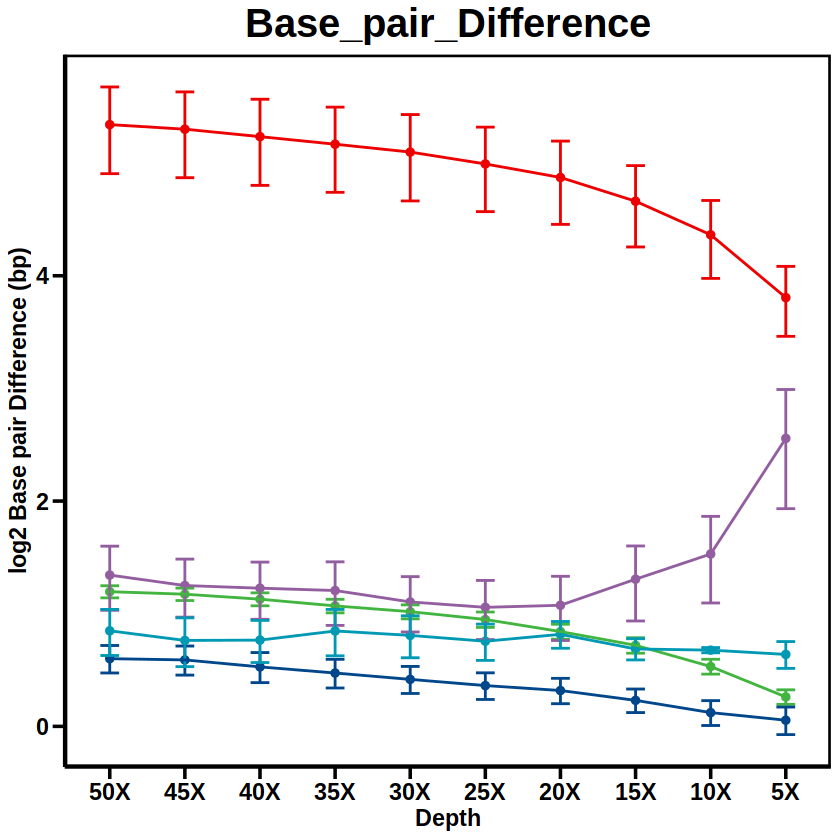

In [160]:
p7 =ggplot(df_combined, aes(x = Depth, y = log2(mean_Base_pair_Difference), , shape = Tools, color = Tools)) +
    geom_point(aes(x = Depth, y = log2(mean_Base_pair_Difference), fill = Tools), shape =19, size = 2) +
    geom_errorbar(aes(x = Depth, ymin = log2(mean_Base_pair_Difference - Base_pair_Difference_se), ymax = log2(mean_Base_pair_Difference + Base_pair_Difference_se)), width = 0.25,linewidth= 0.8) + 
    geom_line(aes(group=Tools,color=Tools), size=0.8) +
    ggsci::scale_fill_lancet() +
    ggsci::scale_color_lancet()+
    ggtitle("Base_pair_Difference")+
    theme_bw()+xlab(label = "Depth")+ylab(label = "log2 Base pair Difference (bp)")+
    theme(
    legend.title = element_blank(),legend.position = "none",
    panel.grid = element_blank(),axis.title = element_text(size=14),
    panel.border = element_rect(fill="NA",color="black", size=1.5, linetype="solid"),
    plot.title = element_text(hjust = 0.5, face="bold", color="black", size=24),
    axis.line=element_line(linewidth=1,colour="black"),
    axis.ticks=element_line(linewidth=1,colour="black"),axis.ticks.length=unit(0.5,"lines"),
    title=element_text(face="bold", colour= "black", size=14),
    axis.text.x = element_text(face="bold", color="black", size=14),
    axis.text.y = element_text(face="bold", color="black", size=14),
    legend.text = element_text(face="bold", color="black", size=14),
    axis.title.x = element_text(face="bold", color="black", size=14),
    axis.title.y = element_text(face="bold",color="black", size=14))

p7
#ggsave(p7, file="Performance_Base_pair_Difference.pdf", w=6,h=6)

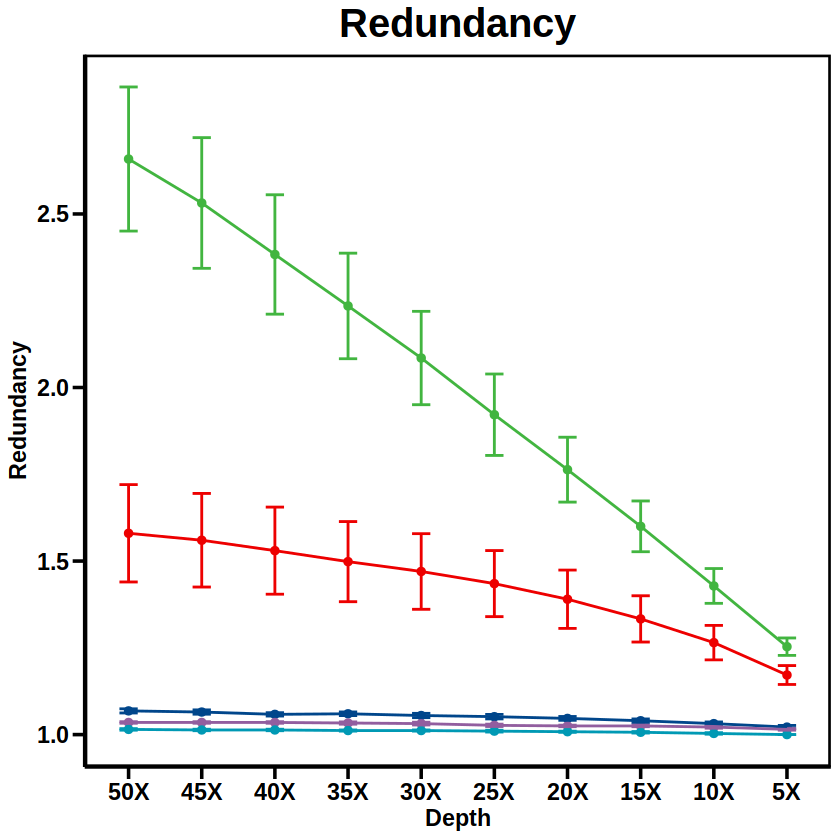

In [161]:
p8 =ggplot(df_combined, aes(x = Depth, y = mean_Redundancy, , shape = Tools, color = Tools)) +
    geom_point(aes(x = Depth, y = mean_Redundancy, fill = Tools), shape =19, size = 2) +
    geom_errorbar(aes(x = Depth, ymin = mean_Redundancy - Redundancy_se, ymax = mean_Redundancy + Redundancy_se), width = 0.25,linewidth= 0.8) + 
    geom_line(aes(group=Tools,color=Tools), size=0.8) +
    ggsci::scale_fill_lancet() +
    ggsci::scale_color_lancet()+
    ggtitle("Redundancy")+
    theme_bw()+xlab(label = "Depth")+ylab(label = "Redundancy")+
    theme(
    legend.title = element_blank(),legend.position = "none",
    panel.grid = element_blank(),axis.title = element_text(size=14),
    panel.border = element_rect(fill="NA",color="black", size=1.5, linetype="solid"),
    plot.title = element_text(hjust = 0.5, face="bold", color="black", size=24),
    axis.line=element_line(linewidth=1,colour="black"),
    axis.ticks=element_line(linewidth=1,colour="black"),axis.ticks.length=unit(0.5,"lines"),
    title=element_text(face="bold", colour= "black", size=14),
    axis.text.x = element_text(face="bold", color="black", size=14),
    axis.text.y = element_text(face="bold", color="black", size=14),
    legend.text = element_text(face="bold", color="black", size=14),
    axis.title.x = element_text(face="bold", color="black", size=14),
    axis.title.y = element_text(face="bold",color="black", size=14))

p8
#ggsave(p8, file="Performance_Redundancy.pdf", w=6,h=6)

In [143]:
library(readr)
library(dplyr)

depths <- c("dataset1", "dataset2", "dataset3", "dataset4", 
            "dataset5", "dataset6", "dataset7")
tools <- c("Deep_EccScan", "CircleMap", "Circle_finder", 
           "ecc_finder", "ECCsplorer")

tool_lists <- lapply(tools, function(x) tibble())
names(tool_lists) <- tools


for (d in depths) {
  for (t in tools) {
    file <- paste0("../01.bwa/50X/", 
                   d, "/", t, "/mummer.pos.matched.coords")
    
    if (file.exists(file)) {
      data <- read_tsv(file, col_names = FALSE, show_col_types = FALSE) %>%
        select(value = 12) %>%
        distinct() %>%
        mutate(dataset = d, tool = t, value = paste0(dataset, "_", value))
      
      tool_lists[[t]] <- bind_rows(tool_lists[[t]], data)
    }
  }
}

In [145]:
for (t in tools) {
  if (nrow(tool_lists[[t]]) > 0) {
    sorted_data <- tool_lists[[t]] %>% 
      select(value) 
    write_tsv(sorted_data, paste0(t, ".tsv"), col_names = FALSE)
  }
}

已保存: Deep_EccScan .tsv ( 67784 行)
已保存: CircleMap .tsv ( 65933 行)
已保存: Circle_finder .tsv ( 63955 行)
已保存: ecc_finder .tsv ( 52049 行)
已保存: ECCsplorer .tsv ( 58634 行)


维恩图已保存为: four_tools_ggvenn .pdf
维恩图已保存为: four_tools_ggvenn .png


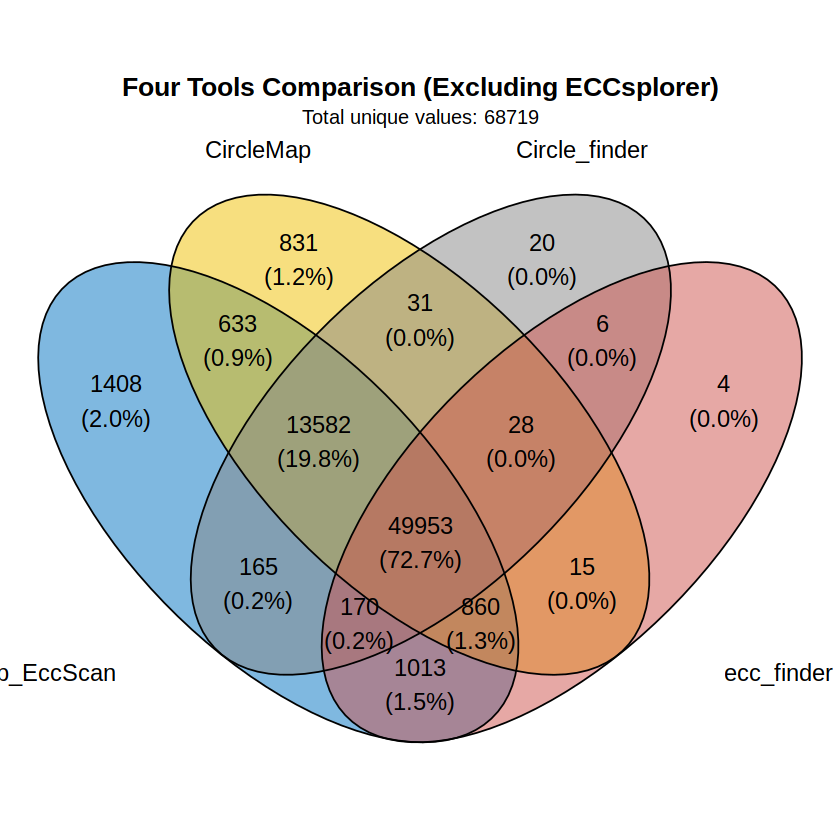

In [148]:
library(ggvenn)
library(dplyr)


draw_ggvenn_4tools <- function(tool_lists, filename = "ggvenn_4tools") {
  selected_tools <- c("Deep_EccScan", "CircleMap", "Circle_finder", "ecc_finder")
  venn_data <- list()
  for (t in selected_tools) {
    if (t %in% names(tool_lists) && nrow(tool_lists[[t]]) > 0) {
      venn_data[[t]] <- unique(tool_lists[[t]]$value)
    } else {
      venn_data[[t]] <- character(0)  
    }
  }

  data_counts <- sapply(venn_data, length)
  
  p <- ggvenn(
    venn_data,
    fill_color = c("#0073C2FF", "#EFC000FF", "#868686FF", "#CD534CFF"),
    stroke_size = 0.5,
    set_name_size = 5,
    text_size = 5,
    show_percentage = TRUE
  ) +
    labs(
      title = "Four Tools Comparison (Excluding ECCsplorer)",
      subtitle = paste("Total unique values:", length(unique(unlist(venn_data))))
    ) +
    theme(
      plot.title = element_text(hjust = 0.5, size = 16, face = "bold"),
      plot.subtitle = element_text(hjust = 0.5, size = 12)
    )
  
  print(p)
  
  ggsave(paste0(filename, ".pdf"), p, width = 10, height = 8)
  
  
  return(p)
}

p9 <- draw_ggvenn_4tools(tool_lists, "four_tools_ggvenn")

In [162]:
P = ggpubr::ggarrange(p1, p2, p3, p4, p5, p6,p7,p8,p9,
                      ncol = 3, nrow=3, 
                      labels="AUTO", common.legend = FALSE
                     )

ggsave(P,file=paste0("Figure3.pdf"),h=18,w=18)

`height` was translated to `width`.
